# Predictive Maintenance — Failure Mode Counts

Counting how often each failure mode (TWF, HDF, PWF, OSF, RNF) occurs in the dataset, to support the case that a binary `Machine failure` label hides useful diagnostic detail.

In [3]:
import pandas as pd

df = pd.read_csv('./data/predictive_maintenance.csv')
df.head()

,Type,Air temperature,Process temperature,Rotational speed,Torque,Tool wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [4]:
failure_modes = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']

mode_counts = df[failure_modes].sum().sort_values(ascending=False)
total_failures = df['Machine failure'].sum()
overlap = (df[failure_modes].sum(axis=1) > 1).sum()

print(f"Total rows: {len(df)}")
print(f"Total Machine failure = 1: {total_failures}")
print(f"Rows with more than one failure mode active: {overlap}")
mode_counts

Total rows: 10000
Total Machine failure = 1: 339
Rows with more than one failure mode active: 24


HDF    115
OSF     98
PWF     95
TWF     46
RNF     19
dtype: int64

<Axes: title={'center': 'Failure Mode Counts'}>

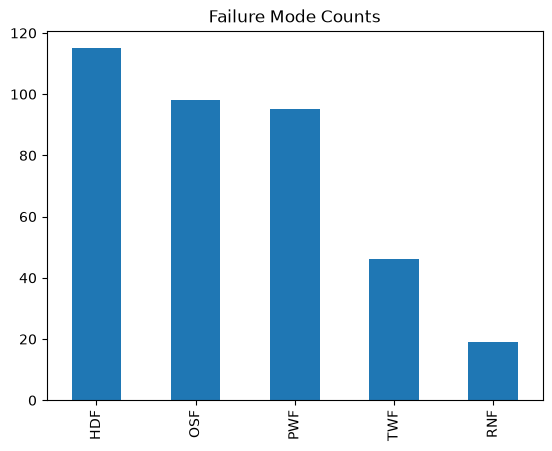

In [5]:
mode_counts.plot(kind='bar', title='Failure Mode Counts')

# Dataset Overview

### 1-Minute Dataset Overview: Milling Machine Predictive Maintenance

This dataset captures 10,000 synthetic operational cycles of a computer numerical control (CNC) milling machine. It models real-time telemetry alongside specific wear mechanics:

* **Type**: Product quality grade (`L` = Low/50%, `M` = Medium/30%, `H` = High/20%), which dictates machining tolerances and feed rates.
* **Air temperature [K]**: Ambient factory floor temperature around the enclosure.
* **Process temperature [K]**: Contact-zone thermal output during active cutting.
* **Rotational speed [rpm]**: Spindle rotation frequency; lower speeds with high loads cause heat buildup, while overspeeding accelerates wear.
* **Torque [Nm]**: Torsional resistance on the spindle drive motor.
* **Tool wear [min]**: Cumulative cutting duration on the currently installed mill bit.
* **Machine failure**: Binary target (0 = nominal operation, 1 = failure event). The dataset is heavily imbalanced: only 339 runs (~3.4%) result in downtime.
* **Failure Modes (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`)**: Operational flags indicating tool wear-out, heat dissipation limits, electrical power mismatch, overstrain, or random hardware breakdown.

**Data Cleanliness**: The dataset is complete and well-structured, with zero missing null values and consistent SI-derived units. No imputation is necessary; processing can proceed straight to sensor normalization and addressing class imbalance.

In [7]:
import pandas as pd


class MaintenanceDataset:
    """Manages the AI4I 2020 predictive maintenance data pipeline and views."""

    def __init__(self, file_path: str = "data/predictive_maintenance.csv"):
        """Loads machine telemetry and initializes standard sensor column definitions."""
        # The CSV headers have no units; add them so every section uses the agreed "[K]"-style names
        self.raw_dataframe = pd.read_csv(file_path).rename(
            columns={
                "Air temperature": "Air temperature [K]",
                "Process temperature": "Process temperature [K]",
                "Rotational speed": "Rotational speed [rpm]",
                "Torque": "Torque [Nm]",
                "Tool wear": "Tool wear [min]",
            }
        )
        self.sensor_column_names = [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]

    @property
    def raw_data(self) -> pd.DataFrame:
        """Returns the complete, unmodified machine telemetry dataframe."""
        return self.raw_dataframe

    @property
    def sensors(self) -> pd.DataFrame:
        """Returns the continuous numeric sensor measurement columns only."""
        return self.raw_dataframe[self.sensor_column_names]

    @property
    def healthy(self) -> pd.DataFrame:
        """Returns records of runs operating without machine failure."""
        return self.raw_dataframe[self.raw_dataframe["Machine failure"] == 0]

    @property
    def failed(self) -> pd.DataFrame:
        """Returns records where machine failure occurred."""
        return self.raw_dataframe[self.raw_dataframe["Machine failure"] == 1]

    def overview(self) -> pd.DataFrame:
        """Returns a combined tabular breakdown of types, missing counts, and shape."""
        overview_table = pd.DataFrame(
            {
                "data_type": self.raw_dataframe.dtypes,
                "missing_values": self.raw_dataframe.isnull().sum(),
                "distinct values": self.raw_dataframe.nunique(),
            }
        )
        print(f"Total Rows: {self.raw_dataframe.shape[0]}, Total Columns: {self.raw_dataframe.shape[1]}")
        return overview_table

In [8]:
# Instantiate the dataset object for use across downstream tasks (Person B & C)
maintenance_dataset = MaintenanceDataset("data/predictive_maintenance.csv")

# Quick inspection of structure, missing values, and property slices
maintenance_dataset.overview()

Total Rows: 10000, Total Columns: 12


,data_type,missing_values,distinct values
Type,str,0,3
Air temperature,float64,0,93
Process temperature,float64,0,82
Rotational speed,int64,0,941
Torque,float64,0,577
Tool wear,int64,0,246
Machine failure,int64,0,2
TWF,int64,0,2
HDF,int64,0,2
PWF,int64,0,2


# Central Tendency and Spread

**Author: Person B**


## Use case summary (50 words)

Manufacturers want to predict machine failure before it happens using
sensor data (temperature, speed, torque, tool wear). By analyzing these
readings statistically, maintenance teams can identify warning patterns,
schedule repairs proactively, avoid unplanned downtime, and reduce costs,
instead of reacting only after equipment already breaks down unexpectedly.

In [ ]:
# Reusing Person A's loader instead of reading the CSV a second time.
df = maintenance_dataset.raw_data
df.head()


In [ ]:
class DescriptiveStats:
    """Computes central tendency and spread statistics for the maintenance dataset."""

    def __init__(self, df):
        """Inits DescriptiveStats with the source dataframe.

        Args:
            df: pandas DataFrame containing the machine-run records.
        """
        self.df = df
        self.numeric_cols = [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]",
        ]

    def central_tendency(self):
        """Computes mean, median, and skewness for each numeric column.

        Returns:
            A pandas DataFrame indexed by column name with columns
            'mean', 'median', and 'skew'.
        """
        rows = {}
        for col in self.numeric_cols:
            rows[col] = {
                "mean": self.df[col].mean(),
                "median": self.df[col].median(),
                "skew": self.df[col].skew(),
            }
        return pd.DataFrame(rows).T

    def categorical_modes(self):
        """Computes the mode of the categorical columns and its frequency.

        Returns:
            A pandas DataFrame with the mode value and count for
            'Type' and 'Machine failure'.
        """
        cat_cols = ["Type", "Machine failure"]
        rows = {}
        for col in cat_cols:
            mode_value = self.df[col].mode()[0]
            mode_count = (self.df[col] == mode_value).sum()
            rows[col] = {"mode": mode_value, "count": mode_count}
        return pd.DataFrame(rows).T

    def spread(self):
        """Computes variance, standard deviation, and coefficient of variation.

        Returns:
            A pandas DataFrame indexed by column name with columns
            'variance', 'std', and 'cv' (std / mean).
        """
        rows = {}
        for col in self.numeric_cols:
            var = self.df[col].var()
            std = self.df[col].std()
            mean = self.df[col].mean()
            rows[col] = {
                "variance": var,
                "std": std,
                "cv": std / mean,
            }
        return pd.DataFrame(rows).T

    def quartiles(self):
        """Computes Q1, median, Q3, max, and IQR for each numeric column.

        Returns:
            A pandas DataFrame indexed by column name with columns
            'q1', 'median', 'q3', 'max', and 'iqr'.
        """
        rows = {}
        for col in self.numeric_cols:
            q1 = self.df[col].quantile(0.25)
            q2 = self.df[col].quantile(0.50)
            q3 = self.df[col].quantile(0.75)
            rows[col] = {
                "q1": q1,
                "median": q2,
                "q3": q3,
                "max": self.df[col].max(),
                "iqr": q3 - q1,
            }
        return pd.DataFrame(rows).T

In [ ]:
stats = DescriptiveStats(df)
central_table = stats.central_tendency()
central_table

In [ ]:
mode_table = stats.categorical_modes()
mode_table

In [ ]:
spread_table = stats.spread()
spread_table

In [ ]:
quartile_table = stats.quartiles()
quartile_table

### Mean vs. median: which one do you trust?

The mean is the right summary when a distribution is roughly symmetric,
because every value pulls it equally in both directions. Once a column has
noticeable skew — a long tail stretching one way — the mean gets dragged
toward that tail, so the median (the middle value, immune to extreme
outliers) becomes the more trustworthy "typical value." Check the skew
column above: anything with `|skew| > 0.5` should be summarized with the
median, not the mean.

### Why mode fits the categorical columns

Mean and median require values that can be ordered and averaged
numerically. `Type` (L/M/H) and `Machine failure` (0/1) are categories, not
quantities — averaging "0.034" failures per row is not a meaningful
statement about a single machine run. The mode simply answers "which
category shows up most often," which is the only central-tendency question
that makes sense for labels.

### Which columns are most/least variable?

Coefficient of variation (CV = std / mean) lets us compare variability
*across* columns that are measured in completely different units and
scales, which raw standard deviation cannot do. A column with a small CV
(like the temperature readings) is tightly controlled by the process; a
column with a larger CV (like torque or tool wear) swings more relative to
its own average, meaning it carries more day-to-day variation for the
process to manage.